# Verified algorithmic lattice surgery of a PyZX graph using Topologiq

This notebook offers an example of how to use ***Topologiq*** to perform an algorithmic lattice surgery (LS) and verify that outputs to ensure the resulting logical computation accurately reflects the input circuit.

It uses a Steane code as example.

In [1]:
import random
random.seed(2)

## PyZX Steane

The first step is, of course, creating the encoding function. Note that the **encoding function can ONLY produce a full version of the Steane**. 

In [2]:
import pyzx as zx
zx.settings.colors = zx.rgb_colors

from pyzx.graph.base import BaseGraph
from pyzx.graph.graph_s import GraphS


def steane_encoding(draw_graph: bool = False) -> BaseGraph | GraphS:
    """Return a PyZX graph of a Steane encoding.

    Args:
        draw_graph: Whether to pop-up PyZX graph visualisation or not.
        use_reduced: Whether to return full or reduced version.

    Returns:
        zx_graph: The PyZX graph corresponding to the requested circuit.

    """

    # Foundational circuit
    pyzx_circuit = zx.Circuit(10)

    ancilla_qubits = [0, 1, 2]
    qubits = [[3, 4, 5, 6], [3, 4, 7, 8], [3, 5, 7, 9]]
    for i, ancilla_qubit in enumerate(ancilla_qubits):
        pyzx_circuit.add_gate("HAD", ancilla_qubit)
        for qubit in qubits[i]:
            pyzx_circuit.add_gate("CNOT", ancilla_qubit, qubit)
        pyzx_circuit.add_gate("HAD", ancilla_qubit)
    zx_graph = pyzx_circuit.to_graph()

    # States & effects
    num_apply_state = zx_graph.num_inputs()
    zx_graph.apply_state("0" * num_apply_state)
    zx_graph.apply_effect("000///////")

    # Draw if needed
    if draw_graph:
        zx.draw(zx_graph, labels=True)

    return zx_graph

Now, instead of asking the circuit directly as a PyZX graph, we will give the encoding to Topologiq's `ZXGraphManager`.

In [3]:
from topologiq.input.pyzx_manager import ZXGraphManager

zx_manager_in = ZXGraphManager()
aug_zx_in = zx_manager_in.add_graph_from_pyzx(zx_graph=steane_encoding(), graph_key="steane")
zx.draw(aug_zx_in.zx_graph, labels=True)

It is possible to modify the bare input graph and create a separate `AugmentedZXGraph` using the same ZX manager.

So, for example, below we remove Hadamards from a reduced version of the graph, and save it to the collection as `steane_pretty`. 

We can do the same for as many versions of a PyZX graph as desired. 
- Create
- Modify
- Add to the collection
- Use the `AugmentedZXGraph` that returns.

In [4]:
steane_pretty = aug_zx_in.zx_graph.copy()
zx.full_reduce(steane_pretty)
zx.to_rg(steane_pretty)

aug_zx_pretty = zx_manager_in.add_graph_from_pyzx(steane_pretty, graph_key="steane_pretty")
zx.draw(aug_zx_pretty.zx_graph, labels=True)

Now, you may wonder why we need an `AugmentedZXGraph` at all if all we're doing is saving PyZX graphs.

The reason is that every time you addd a graph using the `ZXGraphManager`, the resulting `AugmentedZXGraph` will have:
- The foundational PyZX graph
- An automatically-generated `full_reduce` version of the PyZX graph
- A number of methods for visual and algorithmic comparison of inputs and outputs.

So, for example, it is possible to directly draw the reduced versions of both graphs currently in the collection (ps. they should match!).

In [5]:
zx.draw(aug_zx_in.zx_graph_reduced, labels=True)
zx.draw(aug_zx_pretty.zx_graph_reduced, labels=True)

### Lattice surgery

Let's now move to the lattice surgery. 

We can use `get_blockgraph` method of the `AugmentedZXGraph` to perform a lattice surgery on any `AugmentedZXGraph`.

The method will return a different Topologiq object called `BlockGraphManager`, a pimped NX graph that helps maintain equivalences between the input ZX graph and the output lattice surgery.


SUCCESS! Habemus BlockGraph. Volume: 59. Duration: 0.47s



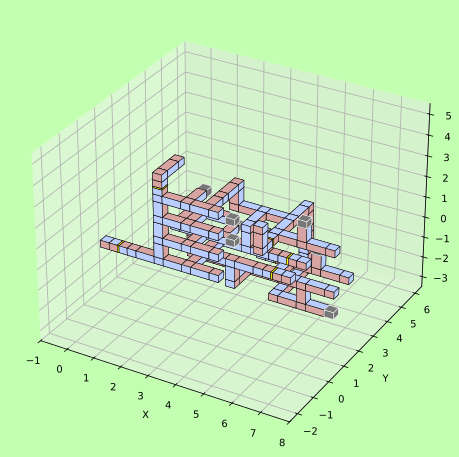

In [6]:
# Lattice surgery on full version
bgraph_manager_full = aug_zx_in.get_blockgraph(use_reduced=False)
bgraph_manager_full.draw_blockgraph()


SUCCESS! Habemus BlockGraph. Volume: 19. Duration: 0.24s



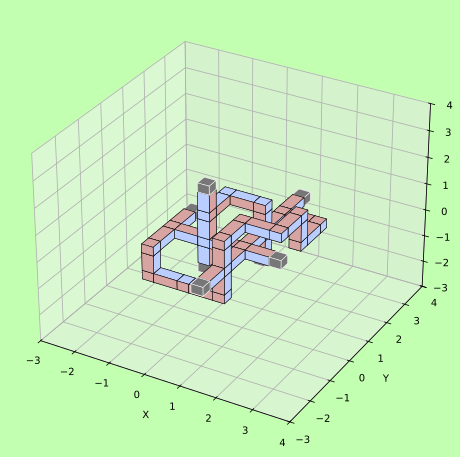

In [7]:
# Lattice surgery on pretty
bgraph_manager_reduced = aug_zx_pretty.get_blockgraph(use_reduced=False)
bgraph_manager_reduced.draw_blockgraph()

The `BlockGraphManager´ object is designed primarily to support forward compilation. In other words, the object has the methods needed to continue the process forward.

Since we will not be using any of that in this notebook, for illustrative purposes, we'll just print the information of one of the blockgraphs created above.

In [8]:
print("Cubes:")
for n, attrs in bgraph_manager_reduced.bgraph.nodes(data=True):
    print(n, attrs)

print("Pipes:")
for u, v, attrs in bgraph_manager_reduced.bgraph.edges(data=True):
    print((u, v), attrs)

Cubes:
10 {'zx_block': ZXBlock(zx_type='Z', kind='XZX'), 'coords': (0, 0, 0), 'completions': {'degree': 4, 'pending': 0}}
11 {'zx_block': ZXBlock(zx_type='X', kind='ZZX'), 'coords': (1, 0, 0), 'completions': {'degree': 4, 'pending': 0}}
13 {'zx_block': ZXBlock(zx_type='X', kind='XZZ'), 'coords': (0, 0, 1), 'completions': {'degree': 3, 'pending': 0}}
15 {'zx_block': ZXBlock(zx_type='X', kind='ZZX'), 'coords': (-1, 0, 0), 'completions': {'degree': 3, 'pending': 0}}
20 {'zx_block': ZXBlock(zx_type='Z', kind='ZXX'), 'coords': (1, 1, 0), 'completions': {'degree': 4, 'pending': 0}}
25 {'zx_block': ZXBlock(zx_type='X', kind='ZZX'), 'coords': (1, 2, 0), 'completions': {'degree': 3, 'pending': 0}}
30 {'zx_block': ZXBlock(zx_type='Z', kind='ZXX'), 'coords': (1, -1, 0), 'completions': {'degree': 4, 'pending': 0}}
43 {'zx_block': ZXBlock(zx_type='O', kind='OOO'), 'coords': (2, 0, 0), 'completions': {'degree': 1, 'pending': 0}}
44 {'zx_block': ZXBlock(zx_type='O', kind='OOO'), 'coords': (0, 0, 2), 

## Verification

Having said that, you can inverse-compile the blockgraph back into an `AugmentedZXGraph`, which will also create a reduced version of the said inverse-compiled ZX.

To perform an equivalence check, you can use the `check_equality` method of any `AugmentedZXGraph` and simply give it another `AugmentedZXGraph`.

If the reduced versions of the graph have inputs and outputs, the tensors will be compared directly.

If the reduced versions of the graph are missing either inputs or outputs, the method will introduce equivalent dummy spiders and edges in all graphs being compared, and then perform the equivalence check.

In [9]:
out_zx_manager = ZXGraphManager()
aug_zx_out = out_zx_manager.add_graph_from_blockgraph(bgraph_manager_reduced, graph_key="steane_out")

equality_1 = aug_zx_out.check_equality(aug_zx_in)
equality_2 = aug_zx_out.check_equality(aug_zx_pretty)

print(
    f"Is the blockgraph that results from LS of the pretty Steane equivalent to the very first original ZX input graph? {equality_1}",
)

Is the blockgraph that results from LS of the pretty Steane equivalent to the very first original ZX input graph? True


In [10]:
equality_2 = aug_zx_out.check_equality(aug_zx_pretty)

print(
    f"\nIs the blockgraph that results from LS of the pretty Steane equivalent to the pretty Steane code ZX input graph? {equality_2}"
)


Is the blockgraph that results from LS of the pretty Steane equivalent to the pretty Steane code ZX input graph? True
